# Marketing Mix Modeling

# Phase 5

## Transformation Selection

Objective

Determine the optimal transformation for each marketing channel after applying the selected adstock decay.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("../src").resolve()))

import pandas as pd
import matplotlib.pyplot as plt

from adstock import geometric_adstock
from transformations import find_best_transformation

In [2]:
cleaned_data = pd.read_csv(
    "../data/processed/raw_data_cleaned.csv"
)

best_adstock = pd.read_csv(
    "../data/processed/best_adstock.csv"
)

In [3]:
transformed_data = cleaned_data.copy()

for _, row in best_adstock.iterrows():

    channel = row["Channel"]

    decay = row["Best_Decay"]

    transformed_data[channel] = geometric_adstock(
        transformed_data[channel],
        decay
    )

transformed_data.head()

,State,Week,Salesforce,Email,Website,TV,Meta,Instagram,Influencer,Year,Month,Quarter,Week_Number,Month_End,Quarter_End,Festival,Holiday,Sales
0,Andhra Pradesh,2023-01-02,496.0000,13205.0000,76588.0000,495.000000,522380.000,1.020933e+06,19.000000,2023,1,1,1,False,False,1,1,564
1,Andhra Pradesh,2023-01-09,2449.4000,23709.5000,97127.2000,920.750000,1364058.000,2.046640e+06,20.150000,2023,1,1,2,False,False,1,1,720
2,Andhra Pradesh,2023-01-16,3944.4600,25990.5500,144896.4800,1186.637500,2660897.200,3.264497e+06,40.127500,2023,1,1,3,False,False,1,1,833
3,Andhra Pradesh,2023-01-23,4815.0140,50582.4950,223136.8320,1234.641875,4281224.480,4.247968e+06,57.108375,2023,1,1,4,False,False,1,1,880
4,Andhra Pradesh,2023-01-30,5586.5126,61927.2455,246186.1488,1457.445594,5339512.032,4.933197e+06,73.542119,2023,1,1,5,True,False,1,1,870


In [4]:
channels = [

    "Salesforce",

    "Email",

    "Website",

    "TV",

    "Meta",

    "Instagram",

    "Influencer"

]

In [5]:
salesforce_results = find_best_transformation(
    transformed_data,
    "Salesforce"
)

salesforce_results

,Transformation,R2,Adjusted_R2,RMSE,MAE,AIC,BIC
0,Linear,0.862847,0.862816,136.595855,91.465695,43234.497902,43247.274803
4,Negative_Exponential,0.862355,0.862324,136.840860,91.219266,43250.253538,43263.030439
2,Root,0.858416,0.858384,138.784854,93.869551,43374.275881,43387.052781
3,Power,0.858416,0.858384,138.784854,93.869551,43374.275881,43387.052781
1,Log,0.821258,0.821218,155.936660,110.467928,44398.763539,44411.540440


In [ ]:
plt.figure(figsize=(10,5))

plt.plot(

    salesforce_results["Transformation"],

    salesforce_results["R2"],

    marker="o"

)

plt.title("Salesforce Transformation Selection")

plt.xlabel("Transformation")

plt.ylabel("R²")

plt.grid(True)

plt.show()

In [6]:
salesforce_results.iloc[0]

Transformation          Linear
R2                    0.862847
Adjusted_R2           0.862816
RMSE                136.595855
MAE                  91.465695
AIC               43234.497902
BIC               43247.274803
Name: 0, dtype: object

In [7]:
best_transformations = []

all_results = {}

for channel in channels:

    print(f"Evaluating {channel}")

    results = find_best_transformation(
        transformed_data,
        channel
    )

    all_results[channel] = results

    best = results.iloc[0]

    best_transformations.append({

        "Channel": channel,

        "Best_Transformation":
            best["Transformation"],

        "R2":
            best["R2"],

        "Adjusted_R2":
            best["Adjusted_R2"],

        "RMSE":
            best["RMSE"],

        "MAE":
            best["MAE"],

        "AIC":
            best["AIC"],

        "BIC":
            best["BIC"]

    })

best_transformations = pd.DataFrame(
    best_transformations
)

best_transformations

Evaluating Salesforce
Evaluating Email
Evaluating Website
Evaluating TV
Evaluating Meta
Evaluating Instagram
Evaluating Influencer


,Channel,Best_Transformation,R2,Adjusted_R2,RMSE,MAE,AIC,BIC
0,Salesforce,Linear,0.862847,0.862816,136.595855,91.465695,43234.497902,43247.274803
1,Email,Negative_Exponential,0.834196,0.834158,150.187322,101.084475,44068.478239,44081.255140
2,Website,Linear,0.834999,0.834961,149.823253,100.206683,44047.139659,44059.916559
3,TV,Negative_Exponential,0.881251,0.881224,127.101427,88.205283,42601.111676,42613.888577
4,Meta,Linear,0.846890,0.846855,144.323715,100.393732,43718.340956,43731.117856
5,Instagram,Linear,0.850273,0.850239,142.720204,99.513668,43620.110573,43632.887474
6,Influencer,Negative_Exponential,0.854247,0.854214,140.813263,98.540135,43501.845340,43514.622241


In [8]:
best_transformations = best_transformations.sort_values(
    "R2",
    ascending=False
)

best_transformations.reset_index(
    drop=True,
    inplace=True
)

best_transformations

,Channel,Best_Transformation,R2,Adjusted_R2,RMSE,MAE,AIC,BIC
0,TV,Negative_Exponential,0.881251,0.881224,127.101427,88.205283,42601.111676,42613.888577
1,Salesforce,Linear,0.862847,0.862816,136.595855,91.465695,43234.497902,43247.274803
2,Influencer,Negative_Exponential,0.854247,0.854214,140.813263,98.540135,43501.845340,43514.622241
3,Instagram,Linear,0.850273,0.850239,142.720204,99.513668,43620.110573,43632.887474
4,Meta,Linear,0.846890,0.846855,144.323715,100.393732,43718.340956,43731.117856
5,Website,Linear,0.834999,0.834961,149.823253,100.206683,44047.139659,44059.916559
6,Email,Negative_Exponential,0.834196,0.834158,150.187322,101.084475,44068.478239,44081.255140


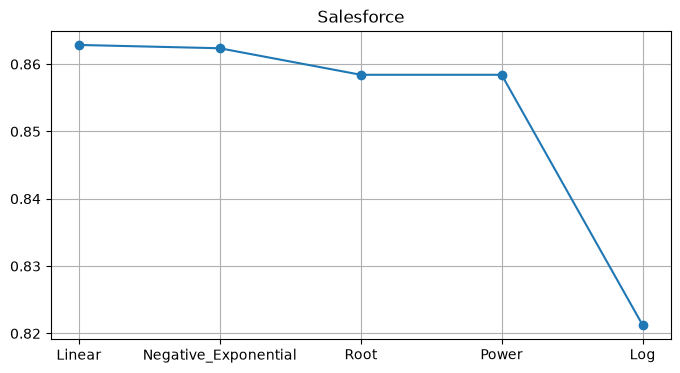

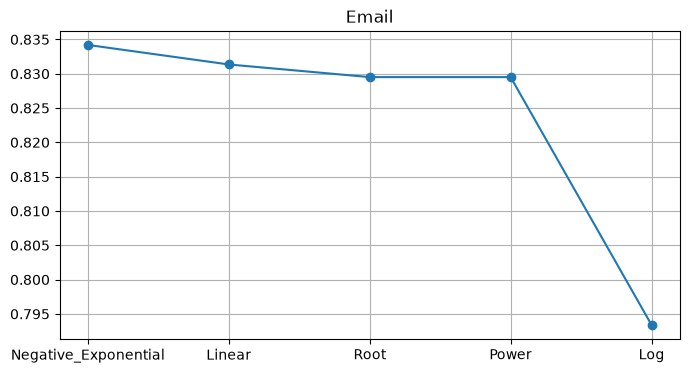

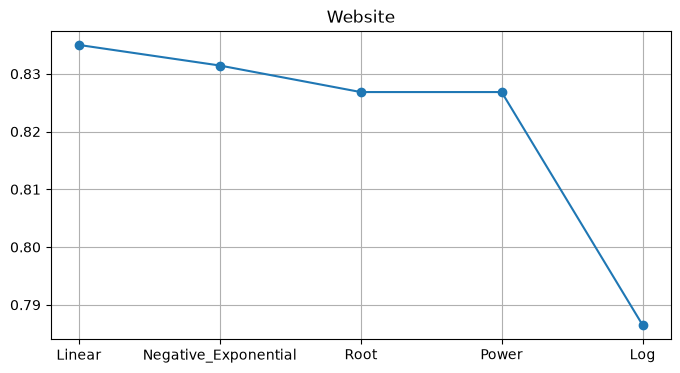

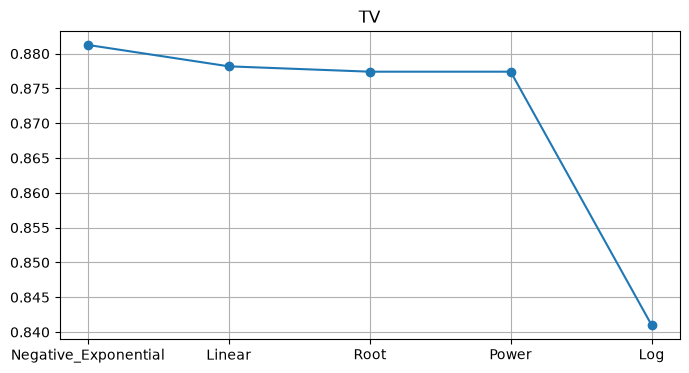

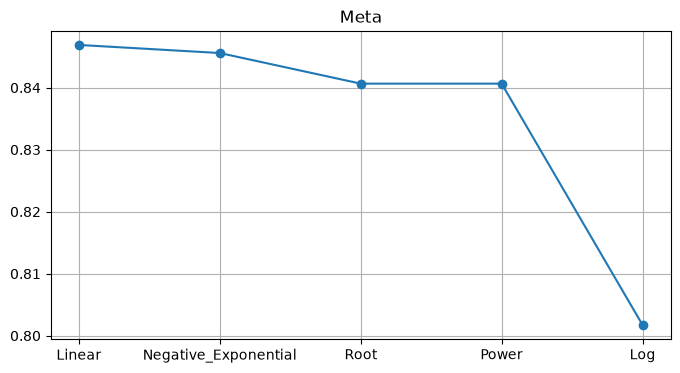

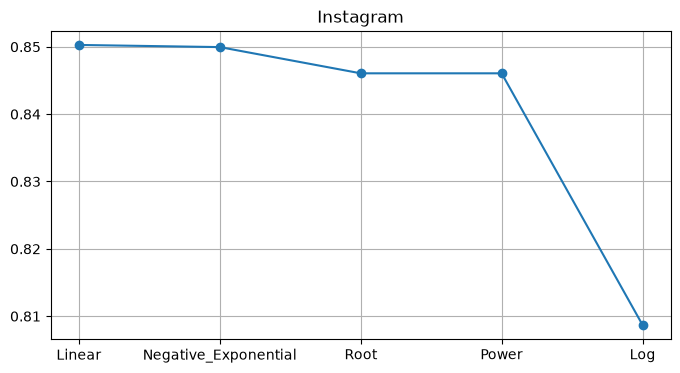

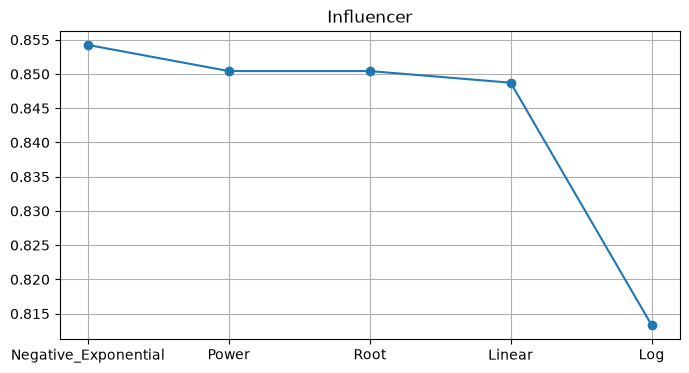

In [9]:
for channel in channels:

    plt.figure(figsize=(8,4))

    results = all_results[channel]

    plt.plot(

        results["Transformation"],

        results["R2"],

        marker="o"

    )

    plt.title(channel)

    plt.grid(True)

    plt.show()

In [10]:
output_folder = Path("../data/processed")

best_transformations.to_csv(

    output_folder /

    "best_transformation.csv",

    index=False

)

print("Transformation selection complete.")

Transformation selection complete.


## Business Interpretation

Different marketing channels exhibit different response curves to increasing activity levels.

Some channels demonstrate a near-linear relationship with sales, while others show diminishing returns that are better represented by logarithmic, root, power, or negative exponential transformations.

The selected transformation for each channel will be used to construct the final modelling dataset in the next phase.